# Running Julia reservoir simulation and optimization from Python

This notebook is a worked end-to-end example of the Julia/JutulDarcy integration in GeoCode.  It mirrors the style of `Basics.ipynb`: every step shows what is being executed, which files are created, how to inspect the data, and how to visualize the results.

We use the Egg model from `open_data/egg` and do four things:

1. run the base Julia simulation from Python;
2. inspect the generated HDF5/JSON artifacts;
3. plot states and well rates with pandas/matplotlib;
4. run a **three-month** BHP optimization and compare base vs optimized production.

Before the first run, instantiate the Julia project once from the repository root:

```bash
julia --project=geocode/bin -e 'using Pkg; Pkg.instantiate()'
```


## Imports and robust project paths

The notebook may be executed from the repository root or from the `notebooks/` directory.  The path setup below detects the project root and then imports the public GeoCode helpers:

* `execute_julia_simulate` → runs `geocode/bin/jutul_run.jl`;
* `execute_julia_optimize` → runs `geocode/bin/jutul_optimize.jl`.


In [1]:
from pathlib import Path
import json
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from geocode import execute_julia_optimize, execute_julia_simulate

plt.rcParams['figure.dpi'] = 110
PROJECT_ROOT

WindowsPath('d:/GitHub/geo-kit/GeoCode')

## Input deck and output directories

The wrappers accept the main `.DATA` file.  For this example the simulation artifacts are written under `open_data/egg/result/`, while optimization artifacts are written under `open_data/egg/optimization/`.


In [2]:
case_path = PROJECT_ROOT / 'open_data' / 'egg' / 'Egg_Model_ECL.DATA'
result_dir = case_path.parent / 'result'
optimization_dir = case_path.parent / 'optimization'

assert case_path.exists(), case_path
{
    'case': str(case_path.relative_to(PROJECT_ROOT)),
    'simulation_output': str(result_dir.relative_to(PROJECT_ROOT)),
    'optimization_output': str(optimization_dir.relative_to(PROJECT_ROOT)),
}


{'case': 'open_data\\egg\\Egg_Model_ECL.DATA',
 'simulation_output': 'open_data\\egg\\result',
 'optimization_output': 'open_data\\egg\\optimization'}

## Run the Julia simulation

The simulation cell starts Julia through the GeoCode wrapper.  The Julia driver exports all data needed for post-processing:

* `manifest.json` — metadata, grid size, well names and column units;
* `states.h5` — pressure and saturation arrays by report date;
* `wells.h5` — one dataset per well under the `wells/` group;
* `cell_indices.h5` — active-cell to natural-grid mapping.


In [3]:
run_dir = execute_julia_simulate(case_path)
run_dir.relative_to(PROJECT_ROOT)

[ Info: Setting up case from d:\GitHub\geo-kit\GeoCode\open_data\egg\Egg_Model_ECL.DATA...
[ Info: Running simulate_reservoir(output_path=d:\GitHub\geo-kit\GeoCode\open_data\egg\result\jutul_state, restart=false)...
Jutul: Simulating 9 years, 44.69 weeks as 120 report steps
Stats: 518 iterations in 50.88 s (98.23 ms each)
╭────────────────┬───────────┬───────────────┬──────────╮
│ Iteration type │  Avg/step │  Avg/ministep │    Total │
│                │ 120 steps │ 154 ministeps │ (wasted) │
├────────────────┼───────────┼───────────────┼──────────┤
│ Newton         │   4.31667 │       3.36364 │  518 (0) │
│ Linearization  │       5.6 │       4.36364 │  672 (0) │
│ Linear solver  │   21.8083 │       16.9935 │ 2617 (0) │
│ Precond apply  │   43.6167 │        33.987 │ 5234 (0) │
╰────────────────┴───────────┴───────────────┴──────────╯
╭───────────────┬─────────┬────────────┬─────────╮
│ Timing type   │    Each │   Relative │   Total │
│               │      ms │ Percentage │       s │
├

WindowsPath('open_data/egg/result')

## Check generated files

A small file listing is the first verification step.  If this cell fails, later HDF5 reads would be misleading, so we assert that the expected files exist.


In [4]:
expected_simulation_files = {'manifest.json', 'states.h5', 'wells.h5', 'cell_indices.h5'}
simulation_files = {p.name for p in run_dir.iterdir()}
missing = expected_simulation_files - simulation_files
assert not missing, missing

pd.DataFrame(
    [{'file': p.name, 'size_kb': round(p.stat().st_size / 1024, 1)} for p in sorted(run_dir.iterdir())]
)


,file,size_kb
0,cell_indices.h5,146.9
1,julia.log,39.4
2,jutul_state,28.0
3,manifest.json,1.2
4,states.h5,52627.0
5,wells.h5,84.8


## Read the simulation manifest

The manifest is intentionally small and human-readable.  It is also the safest source for well names and well-result column order.


In [5]:
manifest = json.loads((run_dir / 'manifest.json').read_text())
manifest_summary = {
    'simulator': manifest['simulator'],
    'jutuldarcy': manifest['jutuldarcy'],
    'grid': manifest['grid'],
    'state_steps': manifest['states']['n_steps'],
    'well_count': len(manifest['wells']['names']),
    'well_columns': manifest['wells']['columns'],
}
manifest_summary


{'simulator': 'jutul',
 'jutuldarcy': '0.3.7',
 'grid': {'nz': 7, 'nx': 60, 'ny': 60, 'n_active': 18553},
 'state_steps': 121,
 'well_count': 12,
 'well_columns': ['time_days', 'WBHP', 'WOPR', 'WWPR', 'WGPR', 'WWIR', 'WGIR']}

## Inspect state arrays

`states.h5` stores dynamic variables as matrices with shape `(n_report_steps, n_active_cells)`.  A row is one reservoir snapshot; a column is the time series of one active cell.


In [6]:
with h5py.File(run_dir / 'states.h5') as h5:
    state_shapes = {name: h5[name].shape for name in h5 if hasattr(h5[name], 'shape')}
    dates = pd.to_datetime([d.decode() if isinstance(d, bytes) else str(d) for d in h5['dates_iso8601'][:]])

{
    'datasets': state_shapes,
    'first_date': dates[0].date().isoformat(),
    'last_date': dates[-1].date().isoformat(),
    'n_dates': len(dates),
}


{'datasets': {'dates_iso8601': (121,),
  'pressure': (121, 18553),
  'soil': (121, 18553),
  'swat': (121, 18553)},
 'first_date': '2011-06-15',
 'last_date': '2021-04-23',
 'n_dates': 121}

### Example: pressure envelope over time

For a quick numerical sanity check, compute min/mean/max pressure over all active cells for each report date.  This is not a replacement for the 3D view, but it immediately shows whether the pressure range is finite and stable.


In [7]:
with h5py.File(run_dir / 'states.h5') as h5:
    pressure = h5['pressure'][:]

pressure_stats = pd.DataFrame({
    'date': dates,
    'min_pressure': pressure.min(axis=1),
    'mean_pressure': pressure.mean(axis=1),
    'max_pressure': pressure.max(axis=1),
})
pressure_stats.tail()


,date,min_pressure,mean_pressure,max_pressure
116,2020-12-24,3.960936e+07,4.014761e+07,4.051783e+07
117,2021-01-23,3.960884e+07,4.014574e+07,4.051552e+07
118,2021-02-22,3.960832e+07,4.014390e+07,4.051324e+07
119,2021-03-24,3.960782e+07,4.014209e+07,4.051101e+07
120,2021-04-23,3.960733e+07,4.014032e+07,4.050882e+07


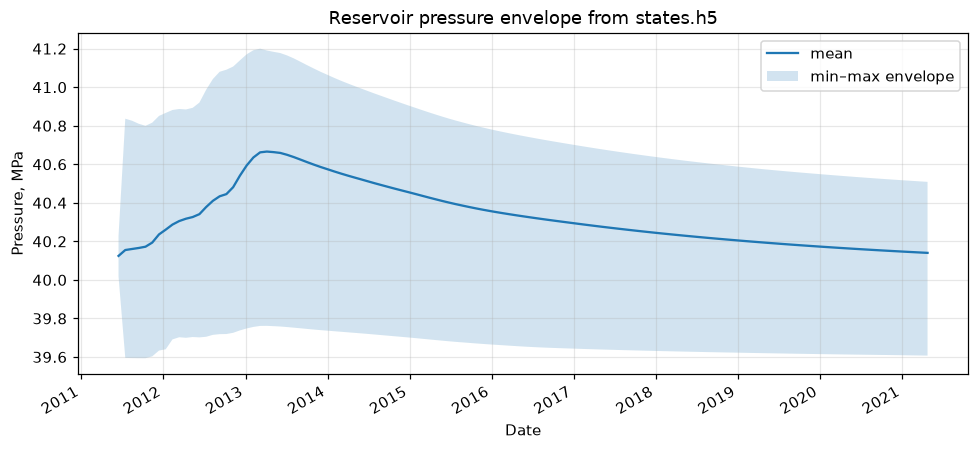

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(pressure_stats['date'], pressure_stats['mean_pressure'] / 1e6, label='mean')
ax.fill_between(
    pressure_stats['date'],
    pressure_stats['min_pressure'] / 1e6,
    pressure_stats['max_pressure'] / 1e6,
    alpha=0.20,
    label='min–max envelope',
)
ax.set_title('Reservoir pressure envelope from states.h5')
ax.set_xlabel('Date')
ax.set_ylabel('Pressure, MPa')
ax.grid(True, alpha=0.3)
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()


### Example: reconstruct one active-cell slice

`cell_indices.h5` maps the compact active-cell vector back to natural grid indices.  The following example reconstructs a single `K` layer from the final pressure state.  Inactive cells stay as `NaN`, which makes the reservoir outline visible in the heatmap.


In [9]:
with h5py.File(run_dir / 'cell_indices.h5') as h5:
    active_to_natural = h5['active_to_natural'][:]

nx, ny, nz = manifest['grid']['nx'], manifest['grid']['ny'], manifest['grid']['nz']
final_pressure_grid = np.full((nz, ny, nx), np.nan)

k = active_to_natural // (nx * ny)
rem = active_to_natural % (nx * ny)
j = rem // nx
i = rem % nx
final_pressure_grid[k, j, i] = pressure[-1]

{
    'active_cells': int(np.isfinite(final_pressure_grid).sum()),
    'grid_shape_kji': final_pressure_grid.shape,
    'selected_k_layer': nz // 2,
}


{'active_cells': 18553, 'grid_shape_kji': (7, 60, 60), 'selected_k_layer': 3}

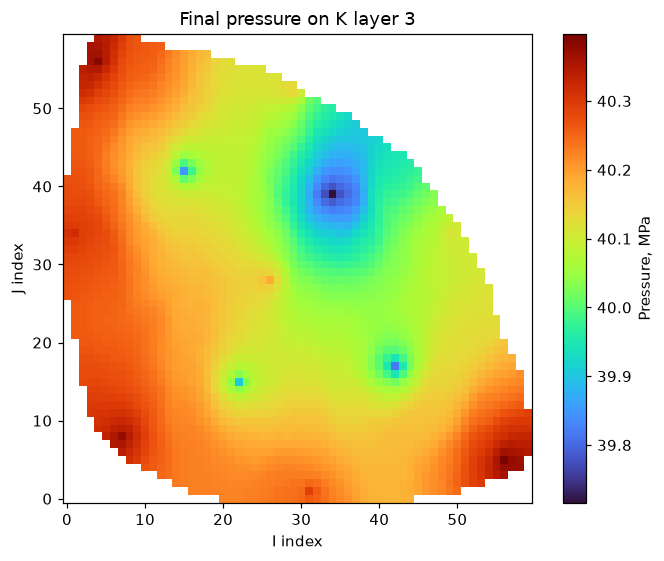

In [10]:
layer = nz // 2
fig, ax = plt.subplots(figsize=(6.5, 5.2))
im = ax.imshow(final_pressure_grid[layer] / 1e6, origin='lower', cmap='turbo')
ax.set_title(f'Final pressure on K layer {layer}')
ax.set_xlabel('I index')
ax.set_ylabel('J index')
fig.colorbar(im, ax=ax, label='Pressure, MPa')
fig.tight_layout()


## 3D pressure field

The 2D `K` slice above is easy to test; a 3D scatter of the active cells gives spatial intuition for the whole grid. Below, every active cell is drawn at its `(I, J, K)` position and coloured by its final-timestep pressure.

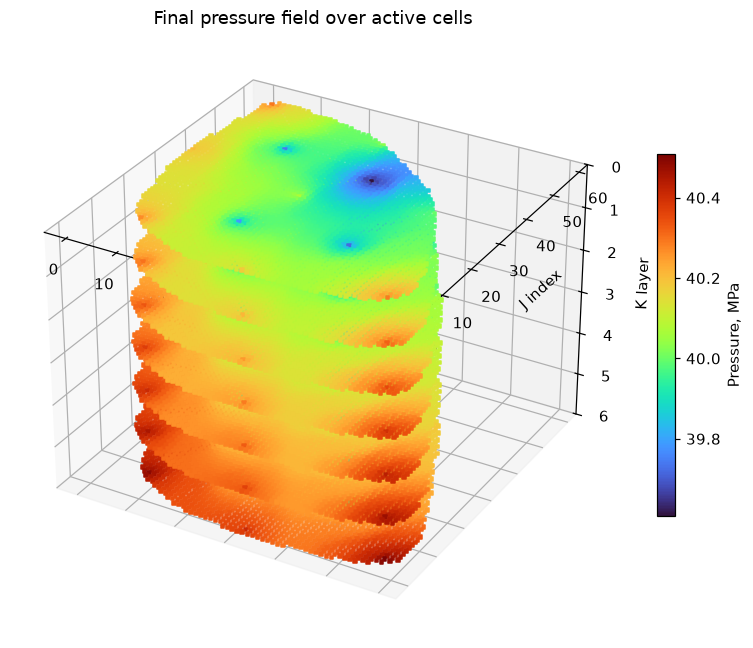

In [11]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3D projection)

kk, jj, ii = np.where(np.isfinite(final_pressure_grid))
vals = final_pressure_grid[kk, jj, ii] / 1e6

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(ii, jj, kk, c=vals, cmap='turbo', marker='s', s=6, depthshade=False)
ax.set_xlabel('I index')
ax.set_ylabel('J index')
ax.set_zlabel('K layer')
ax.set_zlim(nz - 1, 0)  # deeper layers point downward
ax.set_title('Final pressure field over active cells')
fig.colorbar(sc, ax=ax, label='Pressure, MPa', shrink=0.6)
fig.tight_layout()

## Inspect well results

The `wells.h5` file contains a top-level `wells` group.  Each child dataset is one well and uses the column order listed in `manifest['wells']['columns']`.

The group access is important: use the `wells` group first, then index the selected well.  Looking for `PROD1` at the HDF5 root would raise a `KeyError` because it is stored below `wells/`.


In [12]:
well_name = 'PROD1'
well_columns = manifest['wells']['columns']

with h5py.File(run_dir / 'wells.h5') as h5:
    wells_group = h5['wells']
    well_names = sorted(wells_group.keys())
    prod1 = pd.DataFrame(wells_group[well_name][:], columns=well_columns)

well_names[:5], prod1.head()


(['INJECT1', 'INJECT2', 'INJECT3', 'INJECT4', 'INJECT5'],
    time_days   WBHP        WOPR          WWPR  WGPR  WWIR  WGIR
 0       30.0  395.0  132.174435  1.684508e-09   0.0   0.0   0.0
 1       60.0  395.0  132.949010  3.882380e-15   0.0   0.0   0.0
 2       90.0  395.0  133.414487  2.987594e-19   0.0   0.0   0.0
 3      120.0  395.0  133.960671  2.265188e-23   0.0   0.0   0.0
 4      150.0  395.0  137.677850  1.697437e-27   0.0   0.0   0.0)

### Example: producer rates and BHP

`PROD1` is useful for a compact example because the oil and water rates change visibly over the history.  BHP uses a second axis because it has different units from rates.


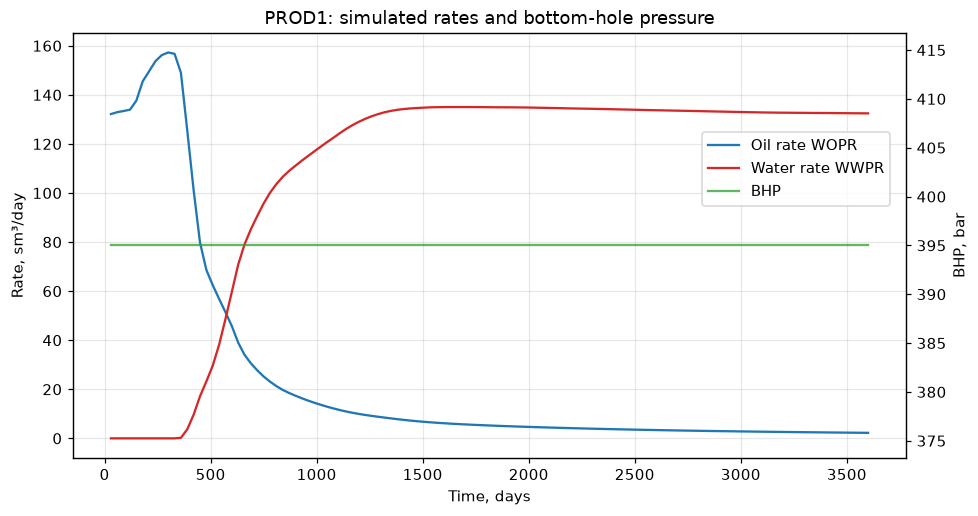

In [13]:
fig, ax_rate = plt.subplots(figsize=(9, 4.8))
ax_bhp = ax_rate.twinx()

ax_rate.plot(prod1['time_days'], prod1['WOPR'], label='Oil rate WOPR', color='tab:blue')
ax_rate.plot(prod1['time_days'], prod1['WWPR'], label='Water rate WWPR', color='tab:red')
ax_bhp.plot(prod1['time_days'], prod1['WBHP'], label='BHP', color='tab:green', alpha=0.75)

ax_rate.set_title(f'{well_name}: simulated rates and bottom-hole pressure')
ax_rate.set_xlabel('Time, days')
ax_rate.set_ylabel('Rate, sm³/day')
ax_bhp.set_ylabel('BHP, bar')
ax_rate.grid(True, alpha=0.3)

lines = ax_rate.get_lines() + ax_bhp.get_lines()
ax_rate.legend(
    lines, [line.get_label() for line in lines],
    loc='center right', bbox_to_anchor=(0.99, 0.68), frameon=True)
fig.tight_layout()


## Run a three-month BHP optimization

The optimization driver starts from the same deck and writes:

* `summary.json` — objective values, convergence, economic settings and optimizer metadata;
* `optimal_bhp.csv` — optimized bottom-hole pressure by month and well;
* `production.csv` — base-vs-optimized rates by month and well.

We intentionally optimize **3 forecast months**, not a one-month toy case, so controls and production response have a visible trajectory across decision periods.


In [14]:
optimization_params = {
    'months': 3,
    'oil-price': 600.0,
    'gas-price': 0.12,
    'water-price': 3.0,
    'water-cost': 3.0,
    'gas-cost': 0.12,
    'discount-rate': 10,
    'max-it': 25,
    'bhp-prod-min': 200,
    'bhp-prod-max': 400,
    'bhp-inj-min': 200,
    'bhp-inj-max': 400,
    'history-cache': str(run_dir / 'jutul_state'),  # reuse the JutulDarcy restart store from the simulation cell
}

optimization_dir = execute_julia_optimize(case_path, params=optimization_params)
optimization_dir.relative_to(PROJECT_ROOT)

Forecast BHP optimization: Egg_Model_ECL.DATA
months=3
[1/5] Loading cached history ...
Jutul: Simulating 9 years, 44.69 weeks as 120 report steps
╭────────────────┬───────────┬───────────────┬──────────╮
│ Iteration type │  Avg/step │  Avg/ministep │    Total │
│                │ 120 steps │ 154 ministeps │ (wasted) │
├────────────────┼───────────┼───────────────┼──────────┤
│ Newton         │   4.31667 │       3.36364 │  518 (0) │
│ Linearization  │       5.6 │       4.36364 │  672 (0) │
│ Linear solver  │   21.8083 │       16.9935 │ 2617 (0) │
│ Precond apply  │   43.6167 │        33.987 │ 5234 (0) │
╰────────────────┴───────────┴───────────────┴──────────╯
╭───────────────┬─────────┬────────────┬─────────╮
│ Timing type   │    Each │   Relative │   Total │
│               │      ms │ Percentage │       s │
├───────────────┼─────────┼────────────┼─────────┤
│ Properties    │  0.4708 │     0.49 % │  0.2439 │
│ Equations     │  4.7673 │     6.47 % │  3.2036 │
│ Assembly      │  2.4749

WindowsPath('open_data/egg/optimization')

## Read optimization outputs

Start with the summary.  The checks below are deliberately explicit: the optimizer must converge, and the recorded forecast length must remain three months.


In [15]:
summary = json.loads((optimization_dir / 'summary.json').read_text())
assert summary['converged'], summary
assert summary['months'] == 3, summary

{
    'converged': summary['converged'],
    'iterations': summary['iterations'],
    'max_iterations': summary.get('max_it'),
    'months': summary['months'],
    'variables': summary['n_variables'],
    'base_npv': round(summary['base_npv'], 2),
    'optimized_npv': round(summary['opt_npv'], 2),
    'improvement_pct': round(summary['improvement_pct'], 2),
}


{'converged': True,
 'iterations': 20,
 'max_iterations': 25,
 'months': 3,
 'variables': 36,
 'base_npv': 494190.83,
 'optimized_npv': 6200858.44,
 'improvement_pct': 1154.75}

## Optimization economics (NPV)

The optimizer's headline numbers — base vs optimized NPV and the relative gain — summarise the economic result. Here they are as a compact bar chart.

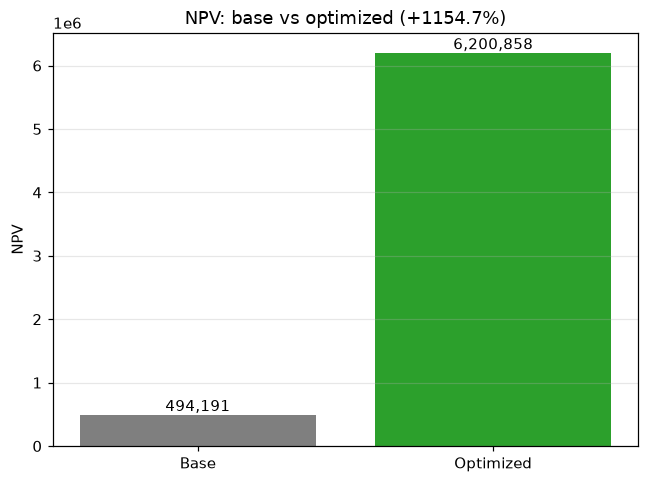

In [16]:
labels = ['Base', 'Optimized']
values = [summary['base_npv'], summary['opt_npv']]

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(labels, values, color=['tab:gray', 'tab:green'])
ax.set_title(f"NPV: base vs optimized (+{summary['improvement_pct']:.1f}%)")
ax.set_ylabel('NPV')
ax.grid(True, axis='y', alpha=0.3)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value, f'{value:,.0f}',
            ha='center', va='bottom')
fig.tight_layout()

In [17]:
bhp = pd.read_csv(optimization_dir / 'optimal_bhp.csv', parse_dates=['start_date', 'end_date'])
production = pd.read_csv(optimization_dir / 'production.csv', parse_dates=['start_date', 'end_date'])

{
    'optimal_bhp_rows': len(bhp),
    'production_rows': len(production),
    'periods': sorted(bhp['period'].unique().tolist()),
    'controls': bhp['control'].nunique(),
    'wells_in_production': production['well'].nunique() if 'well' in production else None,
}


{'optimal_bhp_rows': 36,
 'production_rows': 36,
 'periods': [1, 2, 3],
 'controls': 12,
 'wells_in_production': 12}

## Optimized controls

Each row below is a forecast month and each column is a well control.  Producers and injectors are optimized within their BHP bounds.  The annotation makes it easy to spot wells pushed to high or low pressure limits.


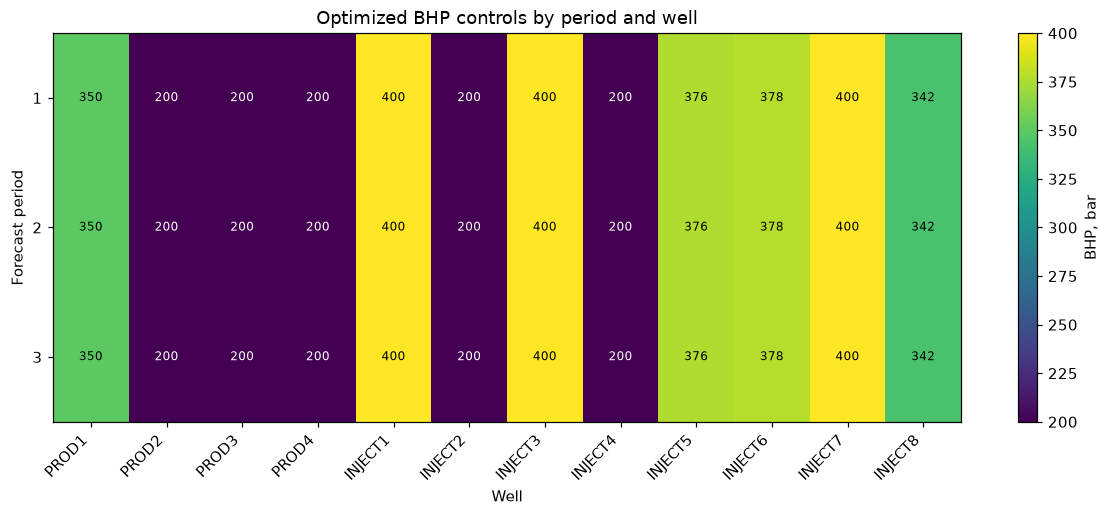

In [18]:
control_order = sorted(bhp['control'].unique(), key=lambda x: (not x.startswith('PROD'), x))
bhp_matrix = bhp.pivot(index='period', columns='control', values='bhp_bar').reindex(columns=control_order)

fig, ax = plt.subplots(figsize=(11, 4.8))
im = ax.imshow(bhp_matrix, aspect='auto', cmap='viridis', vmin=200, vmax=400)
ax.set_title('Optimized BHP controls by period and well')
ax.set_xlabel('Well')
ax.set_ylabel('Forecast period')
ax.set_xticks(range(len(bhp_matrix.columns)), bhp_matrix.columns, rotation=45, ha='right')
ax.set_yticks(range(len(bhp_matrix.index)), bhp_matrix.index)
for row, period in enumerate(bhp_matrix.index):
    for col, well in enumerate(bhp_matrix.columns):
        value = bhp_matrix.loc[period, well]
        ax.text(col, row, f'{value:.0f}', ha='center', va='center', color='white' if value < 300 else 'black', fontsize=8)
fig.colorbar(im, ax=ax, label='BHP, bar')
fig.tight_layout()


## Production response

`production.csv` compares the base and optimized forecast for every well.  Aggregating by period gives a field-level view; grouping by well shows which producers contribute most to the oil-rate uplift.


In [19]:
period_rates = production.groupby('period', as_index=False).agg({
    'base_oil_rate_m3_day': 'sum',
    'opt_oil_rate_m3_day': 'sum',
    'base_gas_rate_m3_day': 'sum',
    'opt_gas_rate_m3_day': 'sum',
    'base_water_rate_m3_day': 'sum',
    'opt_water_rate_m3_day': 'sum',
    'base_water_inj_m3_day': 'sum',
    'opt_water_inj_m3_day': 'sum',
})
period_rates


,period,base_oil_rate_m3_day,opt_oil_rate_m3_day,base_gas_rate_m3_day,opt_gas_rate_m3_day,base_water_rate_m3_day,opt_water_rate_m3_day,base_water_inj_m3_day,opt_water_inj_m3_day
0,1,15.738,279.065,0.0,0.0,620.270,12375.790,636.0,12655.025
1,2,15.546,246.092,0.0,0.0,620.459,12989.984,636.0,13236.112
2,3,15.366,215.966,0.0,0.0,620.639,13542.019,636.0,13757.838


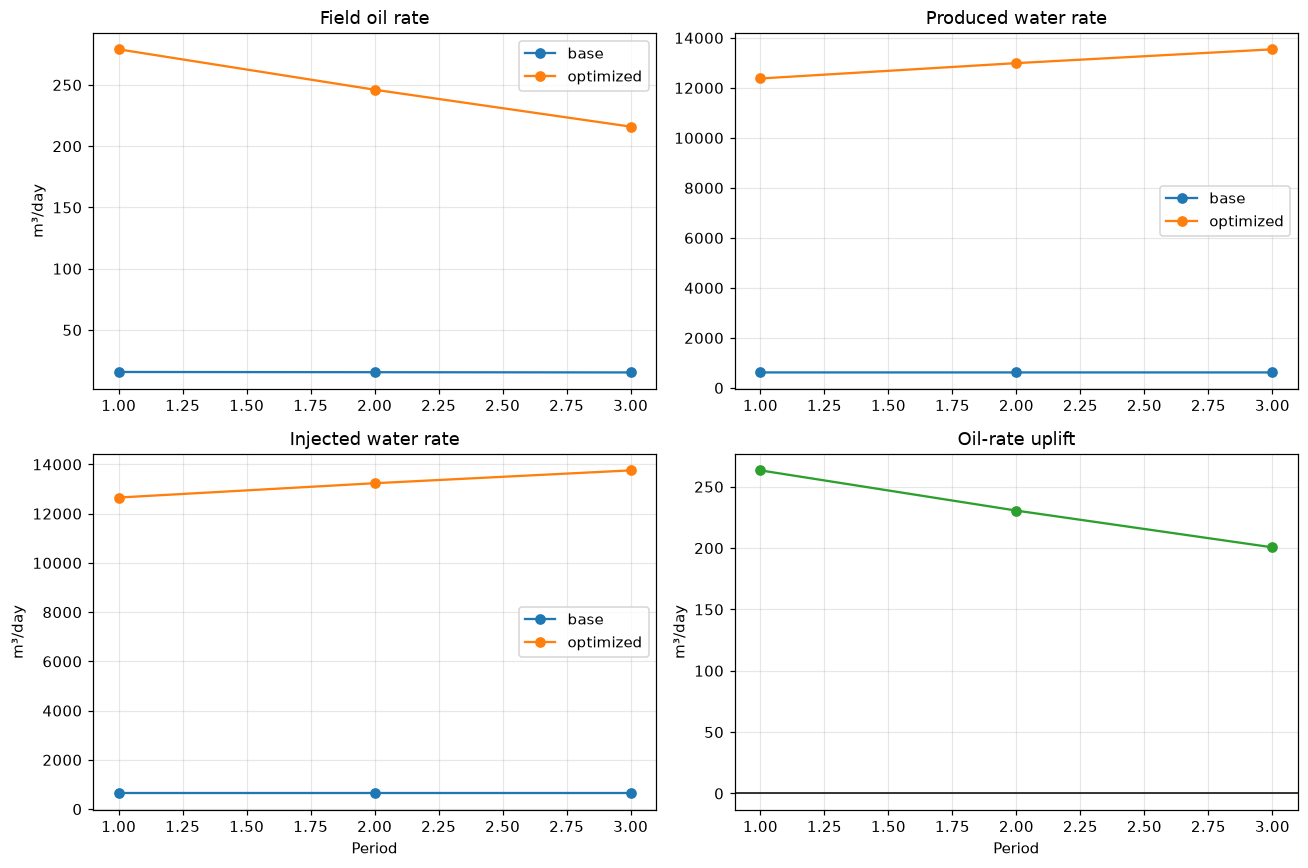

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
periods = period_rates['period']

axes[0, 0].plot(periods, period_rates['base_oil_rate_m3_day'], marker='o', label='base')
axes[0, 0].plot(periods, period_rates['opt_oil_rate_m3_day'], marker='o', label='optimized')
axes[0, 0].set_title('Field oil rate')
axes[0, 0].set_ylabel('m³/day')
axes[0, 0].legend()

axes[0, 1].plot(periods, period_rates['base_water_rate_m3_day'], marker='o', label='base')
axes[0, 1].plot(periods, period_rates['opt_water_rate_m3_day'], marker='o', label='optimized')
axes[0, 1].set_title('Produced water rate')
axes[0, 1].legend()

axes[1, 0].plot(periods, period_rates['base_water_inj_m3_day'], marker='o', label='base')
axes[1, 0].plot(periods, period_rates['opt_water_inj_m3_day'], marker='o', label='optimized')
axes[1, 0].set_title('Injected water rate')
axes[1, 0].set_xlabel('Period')
axes[1, 0].set_ylabel('m³/day')
axes[1, 0].legend()

axes[1, 1].plot(periods, period_rates['opt_oil_rate_m3_day'] - period_rates['base_oil_rate_m3_day'], marker='o', color='tab:green')
axes[1, 1].axhline(0, color='black', linewidth=1)
axes[1, 1].set_title('Oil-rate uplift')
axes[1, 1].set_xlabel('Period')
axes[1, 1].set_ylabel('m³/day')

for ax in axes.ravel():
    ax.grid(True, alpha=0.3)
fig.tight_layout()


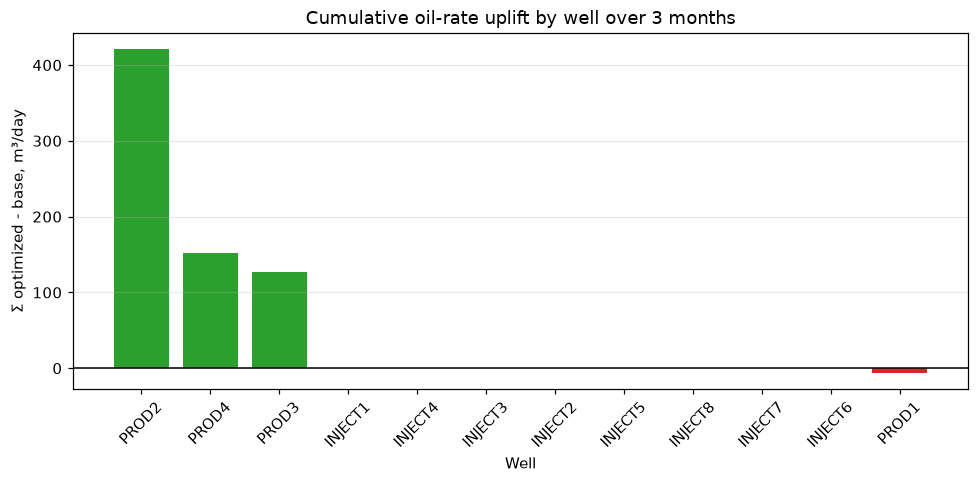

In [21]:
well_uplift = (
    production.assign(oil_uplift=lambda df: df['opt_oil_rate_m3_day'] - df['base_oil_rate_m3_day'])
    .groupby('well', as_index=False)['oil_uplift']
    .sum()
    .sort_values('oil_uplift', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = np.where(well_uplift['oil_uplift'] >= 0, 'tab:green', 'tab:red')
ax.bar(well_uplift['well'], well_uplift['oil_uplift'], color=colors)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Cumulative oil-rate uplift by well over 3 months')
ax.set_xlabel('Well')
ax.set_ylabel('Σ optimized - base, m³/day')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
